# Neural Style Transfer

# Importing Libraries

In [ ]:
pip install tensorflow

In [ ]:
pip install tensorflow-hub

In [ ]:
from matplotlib import gridspec
import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as tf_hub
import PIL
from google.colab import files

# Image Processing Function

In [ ]:
def load_image(image,image_size=(512,512)):
  img = tf.io.read_file(image)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)
  img = tf.image.resize(img, image_size, preserve_aspect_ratio=True)
  img = img[tf.newaxis, :]
  return img


# Uploading Original Image

In [ ]:
upload = files.upload()

Saving content.png to content (2).png


In [ ]:
original_image = load_image("content (2).png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
original_image.shape

TensorShape([1, 410, 512, 3])

# Upload Style Image

In [ ]:
upload=files.upload()

Saving style.png to style (2).png


In [ ]:
Style_image = load_image("style (2).png")

In [ ]:
Style_image.shape

TensorShape([1, 512, 512, 3])

# Display Function

In [ ]:
def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0)

  plt.imshow(image)
  if title:
    plt.title(title)

# Displaying Images

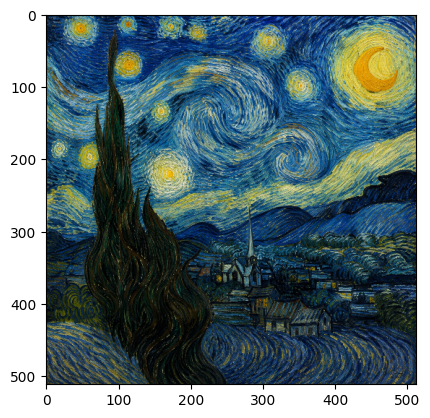

In [ ]:
imshow(Style_image)

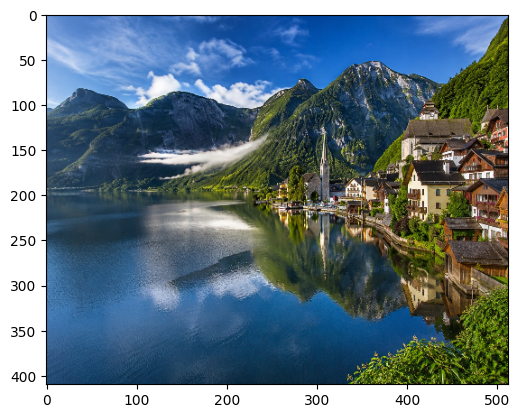

In [ ]:
imshow(original_image)

# Hub Handle

In [ ]:
hub_handle = 'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'

# Hub Module

In [ ]:
hub_module = tf_hub.load(hub_handle)

# Neural Style Transfer

In [ ]:
outputs = hub_module(Style_image,original_image)

In [ ]:
outputs

[<tf.Tensor: shape=(1, 512, 512, 3), dtype=float32, numpy=
 array([[[[0.37072054, 0.5406189 , 0.838873  ],
          [0.389127  , 0.55868775, 0.8419243 ],
          [0.3681434 , 0.5396678 , 0.830014  ],
          ...,
          [0.44100285, 0.60332304, 0.8960511 ],
          [0.47541627, 0.6454077 , 0.9122345 ],
          [0.44305882, 0.6235867 , 0.89346206]],
 
         [[0.36822653, 0.5436708 , 0.8305158 ],
          [0.39360633, 0.5667814 , 0.839072  ],
          [0.37327257, 0.5500357 , 0.8297337 ],
          ...,
          [0.40956432, 0.5745793 , 0.8749853 ],
          [0.42783174, 0.60682356, 0.8883719 ],
          [0.4038043 , 0.58750963, 0.8663652 ]],
 
         [[0.3249131 , 0.48321268, 0.79672676],
          [0.33833537, 0.49836582, 0.8027367 ],
          [0.3109517 , 0.4758847 , 0.78727233],
          ...,
          [0.3774931 , 0.54873717, 0.85764056],
          [0.37795007, 0.565873  , 0.86660784],
          [0.36542848, 0.55537623, 0.8460363 ]],
 
         ...,
 
       

# Displaying Styled Image

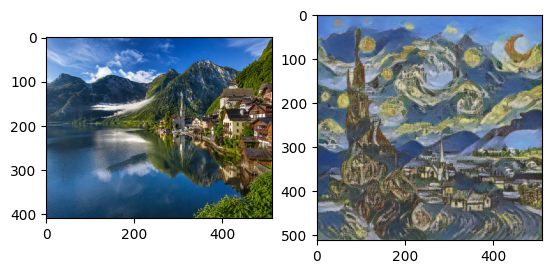

In [ ]:
plt.subplot(1,2,1)
imshow(original_image)
plt.subplot(1,2,2)
imshow(outputs[0])